## Clasificación con perceptrón multicapa (MLP)

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

# Cargar dataset
iris = load_iris()
X = iris.data
y = iris.target

# Convertir a DataFrame para exploración
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = iris.target_names[y]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
from sklearn.neural_network import MLPClassifier

# Crear el modelo MLP
mlp = MLPClassifier(hidden_layer_sizes=(8, 4),    # 2 capas ocultas: 8 y 4 neuronas
                    activation='relu',             # función de activación ReLU
                    solver='adam',                 # optimizador Adam
                    learning_rate_init=0.01,       # tasa de aprendizaje
                    max_iter=1000,                 # número máximo de iteraciones
                    random_state=42)

# Entrenar el modelo
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(8, 4), learning_rate_init=0.01, max_iter=1000,
              random_state=42)

Exactitud del modelo: 1.0

Reporte de clasificación:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



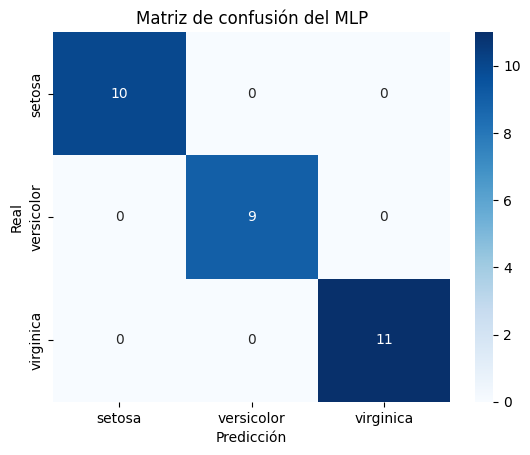

In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones
y_pred = mlp.predict(X_test)

# Métricas
acc = accuracy_score(y_test, y_pred)
print("Exactitud del modelo:", round(acc, 3))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Matriz de confusión del MLP")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

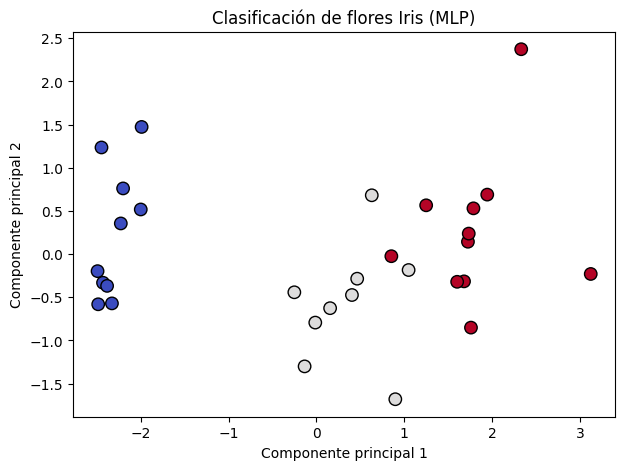

In [5]:
from sklearn.decomposition import PCA

# Reducir a 2 dimensiones para graficar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred, cmap='coolwarm', edgecolor='k', s=80)
plt.title("Clasificación de flores Iris (MLP)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.show()